# SDC (Structural Disconnectome) Analysis

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configurazione estetica per i plot
sns.set_theme(style="whitegrid")


## 1. Validazione Strutturale

Per ogni dataset in scope, contiamo le sottocartelle soggetto in `sdc/` e verifichiamo che ognuna contenga esattamente 15 CSV disconnectome + 16 CSV lesion (31 totali). Solleviamo eccezioni esplicite (`ValueError`) per anomalie.

In [64]:
DATA_ROOT = Path("/Users/emmatosato/Local Projects/Local PhD Projects/NEMESIS_fs/data/clinical_connectome/derivatives")
DATASETS = ["UNIPD/WashU", "UNIPD/PASPORT", "UNIPD/PSP", "UKLFR/stroke_UKLFR"]
TARGET_ATLAS = "schaefer_200_tian_s2"

ATLASES_DISCONNECTOME = [
    "aal", "buckner_7n", "rojkova", "schaefer_200_7n", "schaefer_200_tian_s1", 
    "schaefer_200_tian_s2", "schaefer_300_7n", "schaefer_300_tian_s1", "schaefer_300_tian_s2", 
    "schaefer_400_7n", "schaefer_400_tian_s1", "schaefer_400_tian_s2", "tian_s1", "tian_s2", "yeh_hcp1065"
]
ATLASES_LESION = ATLASES_DISCONNECTOME + ["yeh_hcp1065_streamline"]

subject_sdc_dirs = {}
for dataset in DATASETS:
    sdc_dir = DATA_ROOT / dataset / "sdc"
    if not sdc_dir.exists():
        raise ValueError(f"Directory sdc/ non trovata per {dataset}: {sdc_dir}")
        
    sub_dirs = [d for d in sdc_dir.iterdir() if d.is_dir() and d.name.startswith("sub-")]
    subject_sdc_dirs[dataset] = sub_dirs
    print(f"{dataset:25s} {len(sub_dirs):4d} soggetti in sdc/")

print("\nValidazione CSV in corso...")
for dataset, sub_dirs in subject_sdc_dirs.items():
    for sub_dir in sub_dirs:
        sub_id = sub_dir.name
        dwi_dir = sub_dir / "dwi"
        if not dwi_dir.exists():
            raise ValueError(f"Cartella dwi mancante per il soggetto {sub_id} in {dataset}")
            
        csv_files = list(dwi_dir.glob("*.csv"))
        if len(csv_files) != 31:
            raise ValueError(f"Soggetto {sub_id} in {dataset} ha {len(csv_files)} CSV invece di 31.")
            
print("Validazione completata! Tutti i soggetti analizzati hanno esattamente 31 CSV validi.")


UNIPD/WashU                195 soggetti in sdc/
UNIPD/PASPORT               83 soggetti in sdc/
UNIPD/PSP                  168 soggetti in sdc/
UKLFR/stroke_UKLFR         705 soggetti in sdc/

Validazione CSV in corso...
Validazione completata! Tutti i soggetti analizzati hanno esattamente 31 CSV validi.


## 2. Cross-check soggetti sdc/ vs TSV clinici

Confrontiamo i soggetti in `sdc/` con quelli presenti nei file TSV clinici (`_lesions.tsv`) in `assets/metadata/`.

In [65]:
METADATA_ROOT = Path("/Users/emmatosato/Local Projects/Local PhD Projects/NEMESIS_fs/assets/metadata")
tsv_mapping = {
    "UNIPD/WashU": "UNIPD_WashU_participants_lesions.tsv",
    "UNIPD/PASPORT": "UNIPD_PASPORT_participants_lesions.tsv",
    "UNIPD/PSP": "UNIPD_PSP_participants_lesions.tsv",
    "UKLFR/stroke_UKLFR": "UKLFR_stroke_UKLFR_participants_lesions.tsv"
}

for dataset in DATASETS:
    sdc_dir = DATA_ROOT / dataset / "sdc"
    tsv_file = METADATA_ROOT / tsv_mapping[dataset]
    if not tsv_file.exists():
        raise ValueError(f"File TSV non trovato per {dataset}: {tsv_file}")
        
    sdc_subs = {d.name for d in sdc_dir.iterdir() if d.is_dir() and d.name.startswith("sub-")}
    
    df_tsv = pd.read_csv(tsv_file, sep='\t')
    if 'participant_id' not in df_tsv.columns:
        raise ValueError(f"Colonna 'participant_id' mancante in {tsv_file}")
        
    tsv_subs = set(df_tsv['participant_id'].dropna().unique())
    
    print(f"[{dataset}] -> sdc/: {len(sdc_subs)} | TSV: {len(tsv_subs)}")
    
    only_sdc = sdc_subs - tsv_subs
    only_tsv = tsv_subs - sdc_subs
    
    if only_sdc:
        print(f"  -> {len(only_sdc)} soggetti SOLO in sdc/ : {sorted(list(only_sdc))}")
    if only_tsv:
        print(f"  -> {len(only_tsv)} soggetti SOLO in TSV  : {sorted(list(only_tsv))}")
    print("-" * 60)


[UNIPD/WashU] -> sdc/: 195 | TSV: 202
  -> 7 soggetti SOLO in TSV  : ['sub-STUNIPD0043', 'sub-STUNIPD0087', 'sub-STUNIPD0170', 'sub-STUNIPD0186', 'sub-STUNIPD0204', 'sub-STUNIPD0208', 'sub-STUNIPD0240']
------------------------------------------------------------
[UNIPD/PASPORT] -> sdc/: 83 | TSV: 83
------------------------------------------------------------
[UNIPD/PSP] -> sdc/: 168 | TSV: 168
------------------------------------------------------------
[UKLFR/stroke_UKLFR] -> sdc/: 705 | TSV: 697
  -> 32 soggetti SOLO in sdc/ : ['sub-STUKLFR0005', 'sub-STUKLFR0035', 'sub-STUKLFR0097', 'sub-STUKLFR0132', 'sub-STUKLFR0142', 'sub-STUKLFR0151', 'sub-STUKLFR0155', 'sub-STUKLFR0166', 'sub-STUKLFR0208', 'sub-STUKLFR0236', 'sub-STUKLFR0238', 'sub-STUKLFR0250', 'sub-STUKLFR0264', 'sub-STUKLFR0275', 'sub-STUKLFR0279', 'sub-STUKLFR0336', 'sub-STUKLFR0393', 'sub-STUKLFR0407', 'sub-STUKLFR0427', 'sub-STUKLFR0434', 'sub-STUKLFR0436', 'sub-STUKLFR0439', 'sub-STUKLFR0441', 'sub-STUKLFR0466', 'sub-S

## 3. EDA e Costruzione Matrice Disconnectome

L'atlante scelto è **`schaefer_200_tian_s2`** (200 regioni corticali + 32 sottocorticali).
Prima di caricare, ispezioniamo un CSV per verificare anomalie. 
Poiché i software omettono le regioni con overlap nullo, usiamo `reindex` per allineare matematicamente le feature.

In [66]:
sample_dataset = DATASETS[0]
sample_sub = subject_sdc_dirs[sample_dataset][0]
sample_csv = sample_sub / "dwi" / f"{sample_sub.name}_space-MNI152NLin6Asym_LF-disconnectome_atlas-{TARGET_ATLAS}.csv"

df_sample = pd.read_csv(sample_csv)
print("--- EDA CSV di esempio ---")
print(f"Shape: {df_sample.shape}")
nan_counts = df_sample.isna().sum()
print("NaN rilevati:" if nan_counts.sum() > 0 else "Nessun NaN rilevato.")
if 'region_name' in df_sample.columns:
    dup_regions = df_sample['region_name'].duplicated().sum()
    print(f"Regioni duplicate: {dup_regions}")

display(df_sample.head(3))


--- EDA CSV di esempio ---
Shape: (232, 9)
Nessun NaN rilevato.
Regioni duplicate: 0


,region_name,n_voxels_region,n_voxels_overlap,fraction_covered,mean_overlap,weighted_mean_overlap,sum_overlap,p90_overlap,p95_overlap
0,pGP-lh,720,720,1.0,0.961361,0.961361,692.179778,1.000000,1.0
1,pPUT-lh,3880,3880,1.0,0.738424,0.738424,2865.084274,1.000000,1.0
2,aGP-lh,864,864,1.0,0.671056,0.671056,579.792135,0.994382,1.0


In [69]:
# Ricerca Master List Regioni + caricamento in un solo passaggio
# (invece di leggere ogni CSV due volte)

all_regions: set[str] = set()
subject_dfs: dict[tuple[str, str], pd.DataFrame] = {}  # (dataset, subject_id) -> df
rows_per_subject: dict[str, int] = {}
empty_subjects: list[str] = []

for dataset, sub_dirs in subject_sdc_dirs.items():
    for sub_dir in sub_dirs:
        csv_path = sub_dir / "dwi" / f"{sub_dir.name}_space-MNI152NLin6Asym_LF-disconnectome_atlas-{TARGET_ATLAS}.csv"
        df = pd.read_csv(csv_path)

        if "region_name" not in df.columns:
            raise ValueError(f"{csv_path}: colonna 'region_name' assente — file inatteso, non un caso di dominio")

        dup = df["region_name"].duplicated()
        if dup.any():
            raise ValueError(f"{csv_path}: {dup.sum()} region_name duplicati: {df.loc[dup, 'region_name'].tolist()}")

        if len(df) == 0:
            empty_subjects.append(sub_dir.name)  # tracciato, non solo gestito in silenzio

        rows_per_subject[sub_dir.name] = len(df)
        all_regions.update(df["region_name"].values)
        subject_dfs[(dataset, sub_dir.name)] = df

region_names = np.array(sorted(all_regions))
print(f"Trovate {len(region_names)} regioni uniche per l'atlante {TARGET_ATLAS}.")
if empty_subjects:
    print(f"ATTENZIONE: {len(empty_subjects)} soggetti con CSV completamente vuoto: {empty_subjects}")

# --- Verifica esplicita dell'assunzione "riga mancante = disconnessione zero" ---
# BCBToolkit sembra omettere le regioni a mean_overlap nullo invece di scriverle a 0:
# lo verifichiamo qui sui dati reali invece di limitarci ad assumerlo in un commento.
explicit_zero_rows = sum(
    int((df["mean_overlap"] == 0).sum()) for df in subject_dfs.values()
)
n_incomplete = sum(1 for n in rows_per_subject.values() if n < len(region_names))
print(f"Righe con mean_overlap==0 scritto esplicitamente: {explicit_zero_rows} (atteso 0 se l'assunzione regge)")
print(f"Soggetti con meno righe della master list ({len(region_names)}): {n_incomplete}/{len(rows_per_subject)}")

if explicit_zero_rows > 0:
    raise ValueError(
        f"{explicit_zero_rows} righe con mean_overlap==0 esplicito trovate: l'assunzione "
        "'riga mancante = disconnessione nulla' non è supportata sui dati reali — "
        "va rivista prima di usare fill_value=0.0 nel reindex"
    )

# --- Confronto con la cardinalità nota dell'atlante (se disponibile) ---
# Utile per sapere se la master list osservata è quella completa dell'atlante o
# se alcune regioni non sono MAI disconnesse in nessun soggetto del campione.
KNOWN_ATLAS_SIZES: dict[str, int] = {}  # compila a mano se/quando conosci le taglie reali

if TARGET_ATLAS in KNOWN_ATLAS_SIZES:
    expected_n = KNOWN_ATLAS_SIZES[TARGET_ATLAS]
    if len(region_names) != expected_n:
        print(
            f"ATTENZIONE: master list ha {len(region_names)} regioni, l'atlante "
            f"{TARGET_ATLAS} ne ha {expected_n} — {expected_n - len(region_names)} "
            "regioni mai disconnesse in nessun soggetto del campione"
        )
else:
    max_observed = max(rows_per_subject.values())
    print(
        f"Cardinalità nota per {TARGET_ATLAS!r} non disponibile — proxy empirico: "
        f"max righe in un singolo soggetto = {max_observed}, master list = {len(region_names)}"
    )

# --- Allineamento (ora riusa i df già in memoria, nessuna seconda lettura da disco) ---
features = []
metadata_rows = []

for (dataset, subject_id), df in subject_dfs.items():
    if len(df) == 0:
        feature_vector = np.zeros(len(region_names))
    else:
        series = df.set_index("region_name")["mean_overlap"]
        feature_vector = series.reindex(region_names, fill_value=0.0).values

    features.append(feature_vector)
    metadata_rows.append({"subject_id": subject_id, "dataset": dataset})

X_disco = np.stack(features)
metadata = pd.DataFrame(metadata_rows)

print(f"\nMatrice X_disco finale. Shape: {X_disco.shape}")


Trovate 232 regioni uniche per l'atlante schaefer_200_tian_s2.
ATTENZIONE: 1 soggetti con CSV completamente vuoto: ['sub-STUKLFR0671']
Righe con mean_overlap==0 scritto esplicitamente: 0 (atteso 0 se l'assunzione regge)
Soggetti con meno righe della master list (232): 715/1151
Cardinalità nota per 'schaefer_200_tian_s2' non disponibile — proxy empirico: max righe in un singolo soggetto = 232, master list = 232

Matrice X_disco finale. Shape: (1151, 232)


## 4. Sanity Checks

Ci assicuriamo che la matrice non abbia valori anomali (>1 o <0) e che nessuna regione sia matematicamente costante.

In [47]:
print("--- Sanity Checks ---")
min_val, max_val = X_disco.min(), X_disco.max()
print(f"Valore minimo: {min_val:.4f}, Valore massimo: {max_val:.4f}")
if min_val < 0 or max_val > 1:
    raise ValueError(f"Valori fuori range [0, 1]! min={min_val}, max={max_val}")

nan_count = np.isnan(X_disco).sum()
if nan_count > 0:
    raise ValueError(f"Trovati {nan_count} NaN nella matrice X_disco!")

variance_per_region = np.var(X_disco, axis=0)
constant_regions = np.where(variance_per_region == 0)[0]
print(f"Regioni con varianza zero (costanti): {len(constant_regions)}")


--- Sanity Checks ---
Valore minimo: 0.0000, Valore massimo: 0.9629
Regioni con varianza zero (costanti): 0


## 5. EDA Approfondita

Indaghiamo topologia, carico lesionale globale, vulnerabilità regionale e asimmetrie inter-emisferiche.

--- Statistiche per Dataset ---


,dataset,Soggetti,Mediana_Regioni,Soggetti_Intatti_Perc,Carico_Medio,Carico_Max
0,UKLFR/stroke_UKLFR,705,231.0,0.141844,11.759487,48.492599
1,UNIPD/PASPORT,83,232.0,0.000000,16.694238,45.823111
2,UNIPD/PSP,168,228.5,0.000000,9.994763,47.887329
3,UNIPD/WashU,195,231.0,0.000000,13.017317,45.155129



Top 10 Regioni PIÙ vulnerabili:


,region,freq_percent
231,pPUT-rh,99.739357
204,THA-DA-lh,99.652476
230,pPUT-lh,99.565595
216,aHIP-lh,99.391833
209,THA-VA-rh,99.391833
218,aPUT-lh,99.391833
205,THA-DA-rh,99.304952
211,THA-VP-rh,99.304952
110,7Networks_RH_Cont_PFCmp_2,99.304952
227,pGP-rh,99.218071


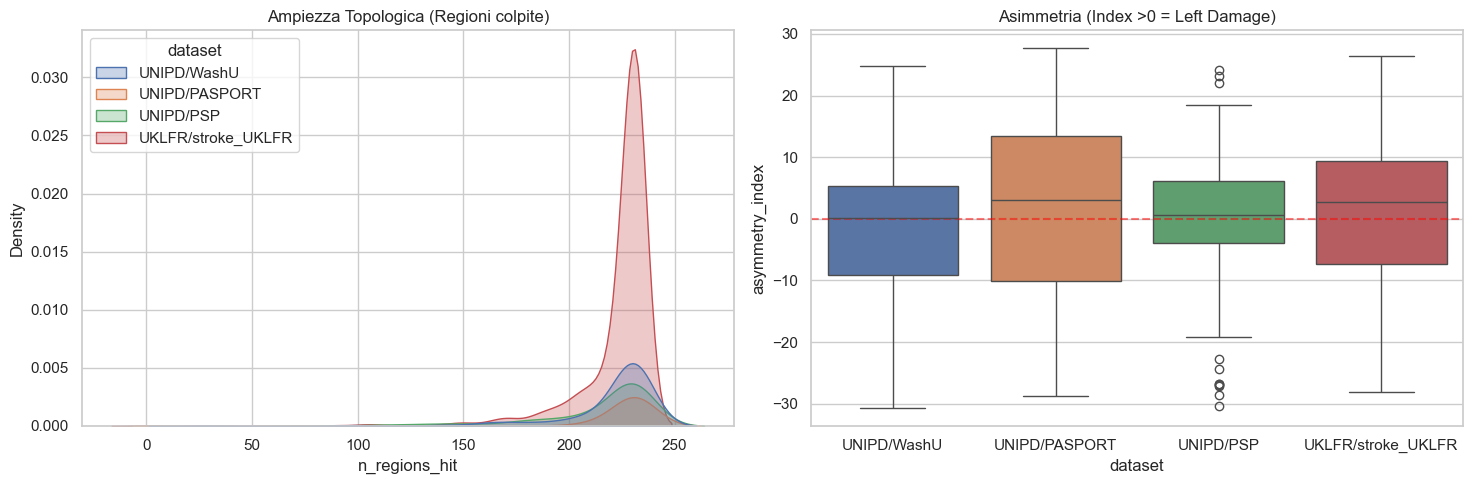

In [61]:
# Aggiunta metriche di carico
metadata['n_regions_hit'] = (X_disco > 0).sum(axis=1)
metadata['disco_load'] = X_disco.sum(axis=1)

# Statistiche Globali
dataset_stats = metadata.groupby('dataset').agg(
    Soggetti=('subject_id', 'count'),
    Mediana_Regioni=('n_regions_hit', 'median'),
    Soggetti_Intatti_Perc=('n_regions_hit', lambda x: (x == 0).mean() * 100),
    Carico_Medio=('disco_load', 'mean'),
    Carico_Max=('disco_load', 'max')
).reset_index()

print("--- Statistiche per Dataset ---")
display(dataset_stats)

# Vulnerabilità Regionale
region_freq = (X_disco > 0).mean(axis=0) * 100
df_regions = pd.DataFrame({'region': region_names, 'freq_percent': region_freq}).sort_values('freq_percent', ascending=False)
print("\nTop 10 Regioni PIÙ vulnerabili:")
display(df_regions.head(10))

# Asimmetria
is_left = np.array(['lh' in r.lower() or '_lh_' in r.lower() for r in region_names])
is_right = np.array(['rh' in r.lower() or '_rh_' in r.lower() for r in region_names])
metadata['load_left'] = X_disco[:, is_left].sum(axis=1)
metadata['load_right'] = X_disco[:, is_right].sum(axis=1)
metadata['asymmetry_index'] = metadata['load_left'] - metadata['load_right']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.kdeplot(data=metadata, x='n_regions_hit', hue='dataset', fill=True, alpha=0.3, ax=axes[0])
axes[0].set_title("Ampiezza Topologica (Regioni colpite)")

sns.boxplot(data=metadata, x='dataset', y='asymmetry_index', ax=axes[1], hue='dataset', legend=False)
axes[1].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[1].set_title("Asimmetria (Index >0 = Left Damage)")
plt.tight_layout()
plt.show()


.